## code for finding and verifying the logical T operator

T_L |0_L> amplitudes: (0.9238795325112866-0.3826834323650898j) 0j
T_L |1_L> amplitudes: 0j (0.9238795325112866+0.3826834323650898j)
⟨0_L|Z_L|0_L⟩ before/after: (1.0000000000000004+0j) (0.9999999999999996+0j)
⟨1_L|Z_L|1_L⟩ before/after: (-1.0000000000000004+0j) (-0.9999999999999996+0j)
T X T† vs S X mags on |0_L>: (0j, (0.7071067811865474-0.7071067811865474j)) (0j, (0.7071067811865476-0.7071067811865476j))
T X T† vs S X mags on |1_L>: ((0.7071067811865474+0.7071067811865474j), 0j) ((0.7071067811865476+0.7071067811865476j), 0j)


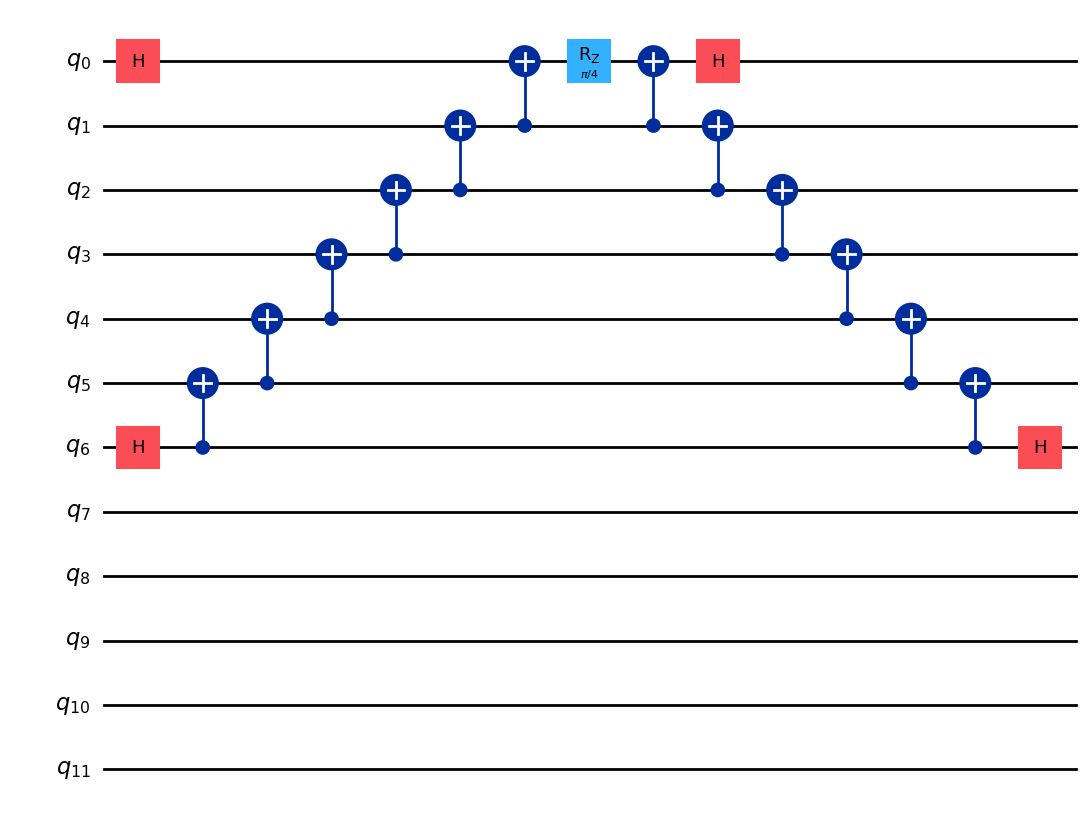

In [3]:
# ===== Part 2: T_L only =====
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp, Pauli, Operator
from qiskit.circuit.library import PauliEvolutionGate

# Parameters
L = 12
theta = np.pi / 4
steps = L // 4

# Helpers
def pauli_from_label(label: str) -> Pauli:
    return Pauli(label[::-1])
def overlap(a: Statevector, b: Statevector) -> complex:
    return complex(np.vdot(a.data, b.data))
def proj_to_code(state, b0, b1):
    return overlap(b0, state), overlap(b1, state)

# Build U = B·A and prepare |0_L>
def circuit_for_A_xx_ring(L, theta, periodic=True):
    qc = QuantumCircuit(L, name="A_xx_RXX")
    phi = 2 * theta
    if periodic:
        for j in range(L):
            qc.rxx(phi, j, (j + 1) % L)
    else:
        for j in range(L - 1):
            qc.rxx(phi, j, j + 1)
    return qc
def circuit_for_B(L, theta):
    qc = QuantumCircuit(L, name="B_field_Z")
    for j in range(L):
        qc.rz(2 * theta, j)
    return qc
def build_U_layer(L, theta, periodic=True):
    A = circuit_for_A_xx_ring(L, theta, periodic)
    B = circuit_for_B(L, theta)
    qc = QuantumCircuit(L, name="U")
    
    qc.compose(A, inplace=True)
    qc.compose(B, inplace=True)
    return qc

U_layer = build_U_layer(L, theta, periodic=True)
psi = Statevector.from_label("0" * L)
for _ in range(steps):
    psi = psi.evolve(U_layer)
ket0L = psi

# Logical Paulis and basis
XL_str = "X" * L
ZL_str = "XZZZZZXIIIII"
X_L_op = SparsePauliOp(pauli_from_label(XL_str))
Z_L_op = SparsePauliOp(pauli_from_label(ZL_str))
ket1L = ket0L.evolve(Operator(X_L_op))

# Build T_L and S_L as gates
def TL_gate(Z_L_op: SparsePauliOp) -> PauliEvolutionGate:
    return PauliEvolutionGate(Z_L_op, time=np.pi / 8)  # exp(-i π/8 Z_L)
def SL_gate(Z_L_op: SparsePauliOp) -> PauliEvolutionGate:
    return PauliEvolutionGate(Z_L_op, time=np.pi / 4)  # exp(-i π/4 Z_L)

T_L_circ = QuantumCircuit(L, name="T_L")
T_L_circ.append(TL_gate(Z_L_op), range(L))

S_L_circ = QuantumCircuit(L, name="S_L")
S_L_circ.append(SL_gate(Z_L_op), range(L))

# Action amplitudes
psi_T0 = ket0L.evolve(T_L_circ)
psi_T1 = ket1L.evolve(T_L_circ)
c0, c1 = proj_to_code(psi_T0, ket0L, ket1L)
d0, d1 = proj_to_code(psi_T1, ket0L, ket1L)
print("T_L |0_L> amplitudes:", c0, c1)
print("T_L |1_L> amplitudes:", d0, d1)

# Conjugation checks on code subspace
# Z_L commutes: expectation preserved
def exp_val(state: Statevector, op: SparsePauliOp):
    return state.expectation_value(Operator(op))
z0_before = exp_val(ket0L, Z_L_op)
z0_after  = exp_val(ket0L.evolve(T_L_circ), Z_L_op)
z1_before = exp_val(ket1L, Z_L_op)
z1_after  = exp_val(ket1L.evolve(T_L_circ), Z_L_op)
print("⟨0_L|Z_L|0_L⟩ before/after:", z0_before, z0_after)
print("⟨1_L|Z_L|1_L⟩ before/after:", z1_before, z1_after)

# Compare T X T† vs S X up to global phase e^{-iπ/4}
SX_circ = QuantumCircuit(L, name="S_L·X_L")
SX_circ.append(SL_gate(Z_L_op), range(L))
SX_circ.append(Operator(X_L_op), range(L))

psi_TXT0 = ket0L.evolve(T_L_circ).evolve(Operator(X_L_op)).evolve(T_L_circ.inverse())
psi_SX0  = ket0L.evolve(SX_circ)
A_TXT = proj_to_code(psi_TXT0, ket0L, ket1L)
A_SX  = proj_to_code(psi_SX0,  ket0L, ket1L)
print("T X T† vs S X mags on |0_L>:",A_TXT,A_SX )

psi_TXT1 = ket1L.evolve(T_L_circ).evolve(Operator(X_L_op)).evolve(T_L_circ.inverse())
psi_SX1  = ket1L.evolve(SX_circ)
B_TXT = proj_to_code(psi_TXT1, ket0L, ket1L)
B_SX  = proj_to_code(psi_SX1,  ket0L, ket1L)
print("T X T† vs S X mags on |1_L>:",B_TXT,B_SX )

# Draw decomposed T_L
T_L_circ.decompose().draw('mpl')

